# Interactive Denoising Lab — PandaOmron + GRPO LoRA

Experiment with GR00T N1.6's flow-matching denoising loop **with the GRPO-trained LoRA adapters injected into the DiT**. Identical layout to `interactive_denoising_panda_v2.ipynb`, except for the new **Cell 2.5** that injects the trained adapters into `lab.model.action_head.model` after the base model is loaded.

`ROBOCASA_PANDA_OMRON` observations captured from the simulator. PandaOmron uses **EEF delta** actions, so the 3D plots show true Cartesian end-effector trajectories.

## Prerequisites

1. **A GRPO LoRA checkpoint** — produced by `scripts/grpo/train_grpo.py` (or `scripts/grpo/toy_train_grpo.py`), e.g. `grpo_data/grpo_checkpoints/iter_0050/lora_weights.pt` or `grpo_data/toy_lr3.0e-5/checkpoints/iter_0004/lora_weights.pt`. Set `LORA_CKPT` in Cell 2.5.

2. **A saved observation `.npz`** — capture at least one with `interactive_rollout.py`:

```bash
# Terminal 1 (model venv)
uv run python gr00t/eval/run_gr00t_server.py \
  --model-path nvidia/GR00T-N1.6-3B \
  --embodiment-tag ROBOCASA_PANDA_OMRON \
  --use-sim-policy-wrapper

# Terminal 2 (sim venv)
gr00t/eval/sim/robocasa/robocasa_uv/.venv/bin/python \
  scripts/denoising_lab/eval/interactive_rollout.py \
  --env-name robocasa_panda_omron/CoffeeServeMug_PandaOmron_Env \
  --host 127.0.0.1 --port 5555 --seed 105 \
  --n-action-steps 8 --max-episode-steps 480 \
  --save-dir ~/results/npz_save_CoffeeServeMug
```

Then press `o` in the interactive rollout to save an observation, and set `OBS_PATH` below to the saved `.npz` file.


In [1]:
# Cell 1: Imports + config
import sys, os
import numpy as np
import torch
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from scripts.denoising_lab.denoising_lab import (
    DenoisingLab, TrajectoryVisualizer, compare_strategies,
)

MODEL_PATH = "nvidia/GR00T-N1.6-3B"
EMBODIMENT_TAG = "robocasa_panda_omron"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Path to observation .npz captured by interactive_rollout.py
OBS_PATH = "/home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step010.npz"

print(f"Device: {DEVICE}")

/home/ubuntu/my_Isaac-GR00T/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [2]:
# Cell 2: Load model
lab = DenoisingLab(MODEL_PATH, EMBODIMENT_TAG, device=DEVICE)
print(f"Model loaded. Action horizon: {lab.action_horizon}, Action dim: {lab.action_dim}")
print(f"Inference timesteps: {lab.num_inference_timesteps}, Timestep buckets: {lab.num_timestep_buckets}")

/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/home/ubuntu/my_Isaac-GR00T/.venv/lib/python3.10/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Tune backbone llm: False
Tune backbone visual: False
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.q_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.k_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.v_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.o_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.q_norm.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.k_norm.weight
Backbone trainable parameter: model.language_model.model.layers.12.mlp.gate_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.mlp.up_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.mlp.down_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.input_layernorm.weight
Backbone trainable parameter: model.language_mode

/home/ubuntu/my_Isaac-GR00T/gr00t/model/modules/dit.py:205: FutureWarning: Accessing config attribute `compute_dtype` directly via 'AlternateVLDiT' object attribute is deprecated. Please access 'compute_dtype' over 'AlternateVLDiT's config object instead, e.g. 'unet.config.compute_dtype'.
  embedding_dim=self.inner_dim, compute_dtype=self.compute_dtype
/home/ubuntu/my_Isaac-GR00T/gr00t/model/modules/dit.py:236: FutureWarning: Accessing config attribute `output_dim` directly via 'AlternateVLDiT' object attribute is deprecated. Please access 'output_dim' over 'AlternateVLDiT's config object instead, e.g. 'unet.config.output_dim'.
  self.proj_out_2 = nn.Linear(self.inner_dim, self.output_dim)


Total number of DiT parameters:  1091722240
Using AlternateVLDiT for diffusion model


`use_fast` is set to `True` but the image processor class does not have a fast version.  Falling back to the slow version.


Tune action head projector: True
Tune action head diffusion model: True
Tune action head vlln: True


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.66it/s]


Model loaded. Action horizon: 50, Action dim: 128
Inference timesteps: 4, Timestep buckets: 1000


In [3]:
# Cell 2.5: Inject the GRPO-trained LoRA adapters into the DiT
#
# `apply_lora_to_dit` freezes every base param and injects rank-r LoRA into
# nn.Linear modules inside `lab.model.action_head.model` (AlternateVLDiT).
# `load_lora_checkpoint` does a strict two-sided key match + per-key shape
# check — it HARD-FAILS if rank/alpha/target_modules here disagree with what
# was used at training time, so a mismatched config can't silently degrade
# the trajectory. Defaults below match GRPOConfig defaults
# (rank=16, alpha=32, dropout=0.0, DEFAULT_LORA_TARGET_MODULES).
#
# Caveats:
#  - LoRA only touches the DiT (not the Eagle backbone), so Cell 6
#    `lab.encode_features_from_sim_obs(...)` is unaffected and any cached
#    `features` from a base-model run remains valid input to a LoRA `denoise`.
#  - PEFT's `inject_adapter_in_model` creates the new Linear submodules at
#    default device/dtype. The `lab.model.action_head.model.to(...)` call
#    below pins the freshly-injected LoRA matrices to the same
#    device/bfloat16 as the rest of the DiT — without it you'd get a
#    cross-device or cross-dtype error on the first `lab.denoise(...)` call.
#  - `requires_grad=True` is set on the LoRA params by `inject_adapter_in_model`,
#    but `Gr00tPolicy` runs the denoising loop inside `torch.inference_mode()`
#    (`gr00t/policy/gr00t_policy.py:347`), so no autograd graph is built —
#    inference cost is just the extra LoRA matmuls.
#  - Only `lora_weights.pt` is read; `optimizer.pt` in the checkpoint dir is
#    ignored (it's needed only for resuming training).

import sys as _sys
_grpo_dir = os.path.join(REPO_ROOT, "scripts", "grpo")
if _grpo_dir not in _sys.path:
    _sys.path.insert(0, _grpo_dir)

from lora_dit import apply_lora_to_dit, load_lora_checkpoint, print_trainable_params, merge_lora_weights

LORA_CKPT = os.path.join(REPO_ROOT, "grpo_data/toy_lr3.0e-5_v3/checkpoints/iter_0004")
# Or:    os.path.join(REPO_ROOT, "grpo_data/grpo_checkpoints/iter_0004")

apply_lora_to_dit(lab.model, rank=16, alpha=32, dropout=0.0)
load_lora_checkpoint(lab.model, LORA_CKPT)

# Pin freshly-injected LoRA Linears to the DiT's device/dtype.
lab.model.action_head.model.to(device=lab.device, dtype=lab.dtype)

# Merge LoRA into base weights (irreversible) for inference speed.
# Collapses the PEFT overlay (Wx + (alpha/r)*B*A*x) into a single fused
# (W')x, removing the per-Linear extra matmul + Python adapter dispatch
# on every forward pass. With ~194 wrapped Linears in the DiT and 4
# Euler steps per denoise(), this saves ~10s on a 100-seed sweep on
# this VM. Mathematically equivalent to leaving LoRA unmerged; bf16
# rounding may produce ULP-level drift but no behavioral change.
# Skip this line if you want to resume training the adapter.
merge_lora_weights(lab.model)

print(f"\nLoRA checkpoint loaded from: {LORA_CKPT}")
print_trainable_params(lab.model)  # ~20M LoRA params, rest frozen


  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/toy_lr3.0e-5_v3/checkpoints/iter_0004

LoRA checkpoint loaded from: /home/ubuntu/my_Isaac-GR00T/grpo_data/toy_lr3.0e-5_v3/checkpoints/iter_0004
Trainable params: 14,532,608 / 3,301,141,440 (0.44%)
  LoRA params:  ~14,532,608
  Frozen params: ~3,286,608,832


{'trainable': 14532608, 'total': 3301141440, 'percentage': 0.44022978912409155}

In [4]:
# Cell 3: Load observation from .npz saved by interactive_rollout.py
obs = DenoisingLab.load_observation(OBS_PATH)
print("Observation loaded from:", OBS_PATH)
print("Keys:", list(obs.keys()))
for k, v in obs.items():
    if isinstance(v, np.ndarray):
        print(f"  {k}: shape={v.shape}, dtype={v.dtype}")
    else:
        print(f"  {k}: {v}")

Observation loaded from: /home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step010.npz
Keys: ['state.base_position', 'state.base_rotation', 'state.end_effector_position_absolute', 'state.end_effector_position_relative', 'state.end_effector_rotation_absolute', 'state.end_effector_rotation_relative', 'state.gripper_qpos', 'state.gripper_qvel', 'state.joint_position', 'state.joint_position_cos', 'state.joint_position_sin', 'state.joint_velocity', 'video.res256_image_side_0', 'video.res256_image_side_1', 'video.res256_image_wrist_0', 'video.res512_image_side_0', 'video.res512_image_side_1', 'video.res512_image_wrist_0', 'annotation.human.action.task_description']
  state.base_position: shape=(1, 1, 3), dtype=float32
  state.base_rotation: shape=(1, 1, 4), dtype=float32
  state.end_effector_position_absolute: shape=(1, 1, 3), dtype=float32
  state.end_effector_position_relative: shape=(1, 1, 3), dtype=float32
  state.end_effector_rotation_absolute: shape=(1, 1, 4), dtype=float32
  state

In [5]:
# Cell 4
print("Command to VLA: ")
print(obs["annotation.human.action.task_description"])

Command to VLA: 
('pick the mug from under the coffee machine dispenser and place it on the counter',)


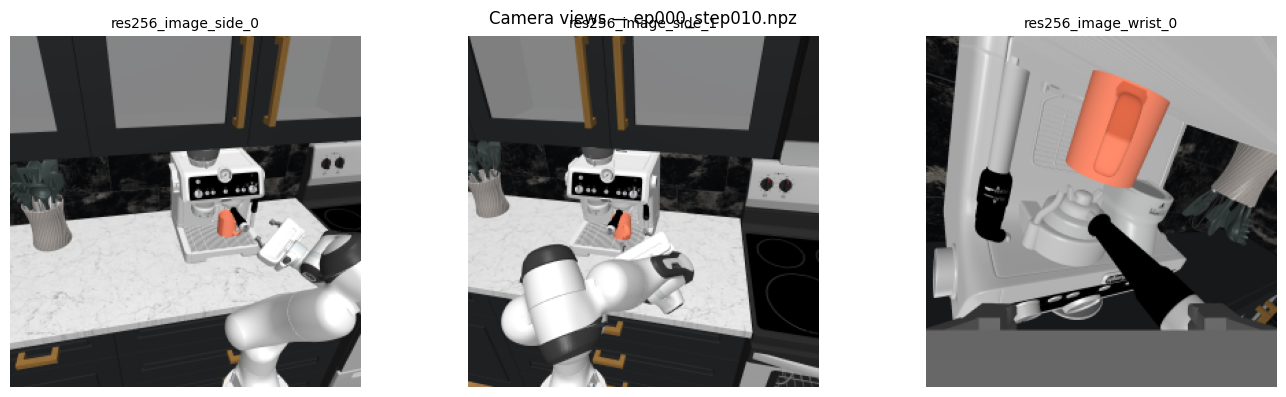

In [6]:
# Cell 5: Visualize camera views from the saved observation
# Shows what the robot sees — helps identify which .npz to experiment with
fig = DenoisingLab.plot_camera_views(obs, figsize=(14, 4))
plt.suptitle(f"Camera views — {OBS_PATH.split('/')[-1]}", fontsize=12)
plt.show()

In [7]:
# Cell 6: Encode backbone features (EXPENSIVE — run once)
features = lab.encode_features_from_sim_obs(obs)
print(f"Backbone features: {features.backbone_features.shape}")
print(f"State features: {features.state_features.shape}")
print(f"Embodiment ID: {features.embodiment_id}")

Backbone features: torch.Size([1, 295, 2048])
State features: torch.Size([1, 1, 1536])
Embodiment ID: tensor([13], device='cuda:0')


In [8]:
# Cell 7: Default denoising (4-step flow matching)
result = lab.denoise(features, seed=42)     # this does actual denoising, 4-step Euler baseline, with same noise vector
print(f"Final action shape: {result.action_pred.shape}")
print(f"Seed: {result.seed}")
for info in result.intermediates:
    print(f"  Step {info.step}: t_cont={info.t_cont:.3f} t_disc={info.t_discretized} "
          f"action_norm={info.action_norm:.4f} velocity_norm={info.velocity_norm:.4f}")

Final action shape: torch.Size([1, 50, 128])
Seed: 42
  Step 0: t_cont=0.000 t_disc=0 action_norm=77.8052 velocity_norm=30.7061
  Step 1: t_cont=0.250 t_disc=250 action_norm=77.2563 velocity_norm=31.3105
  Step 2: t_cont=0.500 t_disc=500 action_norm=77.5626 velocity_norm=32.0851
  Step 3: t_cont=0.750 t_disc=750 action_norm=78.7815 velocity_norm=33.0689


In [9]:
# Cell 8: Decode + inspect actions
decoded = lab.decode_raw_actions(result.action_pred, features.states)
print("Decoded action keys (PandaOmron EEF):")
for key, arr in decoded.items():
    print(f"  {key}: shape={arr.shape}")

for t in range(min(3, list(decoded.values())[0].shape[1])):
    print(lab.label_action_step(decoded, t))

Decoded action keys (PandaOmron EEF):
  end_effector_position: shape=(1, 16, 3)
  end_effector_rotation: shape=(1, 16, 3)
  gripper_close: shape=(1, 16, 1)
  base_motion: shape=(1, 16, 4)
  control_mode: shape=(1, 16, 1)
Step 0:
  end_effector_position: [+0.4492 +0.2754 -0.1875]
  end_effector_rotation: [+0.1504 +0.2773 +0.0098]
  gripper_close: [+0.0000]
  base_motion: [+0.0000 +0.0000 +0.0000 +0.0000]
  control_mode: [+0.0000]
Step 1:
  end_effector_position: [+0.4121 +0.2539 -0.1973]
  end_effector_rotation: [+0.1543 +0.2969 -0.0039]
  gripper_close: [+0.0000]
  base_motion: [+0.0000 +0.0000 +0.0000 +0.0000]
  control_mode: [+0.0000]
Step 2:
  end_effector_position: [+0.3672 +0.2324 -0.2041]
  end_effector_rotation: [+0.1426 +0.2812 +0.0137]
  gripper_close: [+0.0000]
  base_motion: [+0.0000 +0.0000 +0.0000 +0.0000]
  control_mode: [+0.0000]


Plotting EEF trajectory using key: 'end_effector_position'


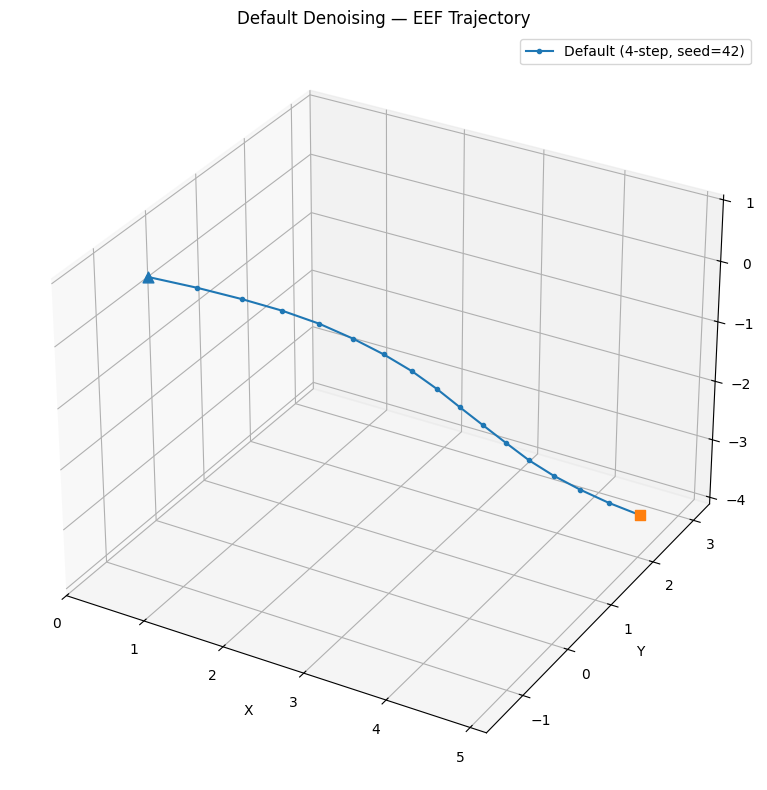

In [10]:
# Cell 9: 3D EEF trajectory plot
EEF_KEY = "end_effector_position"
print(f"Plotting EEF trajectory using key: '{EEF_KEY}'")

viz = TrajectoryVisualizer()
viz.add_trajectory(decoded, "Default (4-step, seed=42)", eef_key=EEF_KEY)
fig = viz.plot_eef_3d(title="Default Denoising — EEF Trajectory")
plt.show()

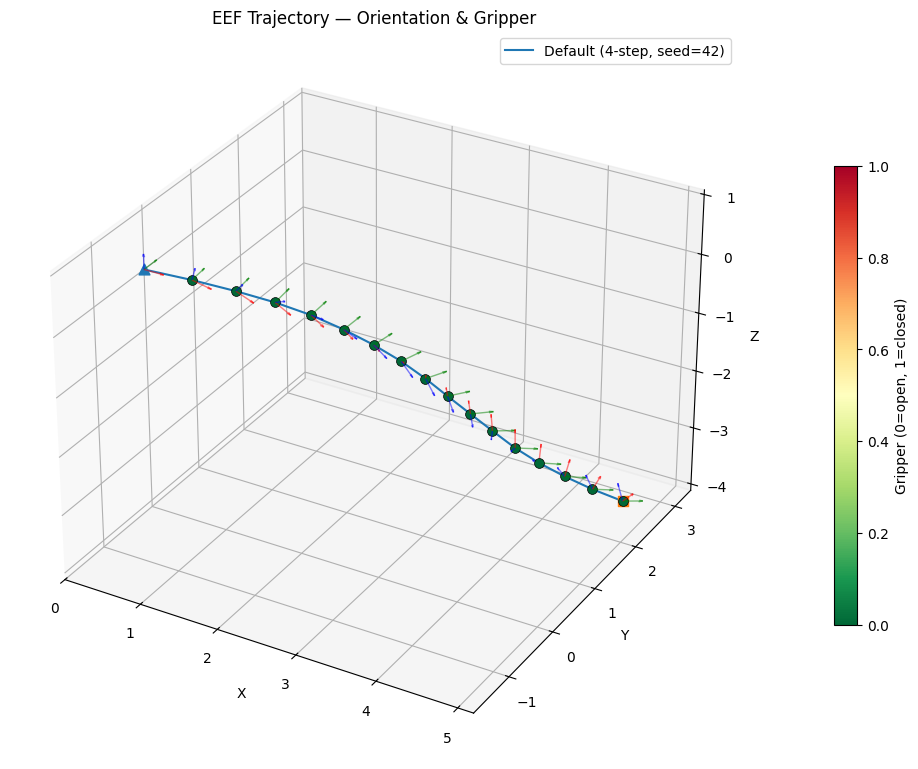

In [11]:
# Cell 10: 3D EEF trajectory with orientation frames and gripper state
# Same trajectory as above, but with mini RGB coordinate frames (R=X, G=Y,
# B=Z) showing accumulated EEF orientation from axis-angle deltas, and
# green→red coloured markers for gripper state (green=open, red=closed).
#
# Toggle show_orientation / show_gripper to enable/disable independently.
# frame_stride controls how often orientation frames are drawn (1=every step).

viz_full = TrajectoryVisualizer()
viz_full.add_trajectory(decoded, "Default (4-step, seed=42)", eef_key=EEF_KEY)

fig = viz_full.plot_eef_3d(
    title="EEF Trajectory — Orientation & Gripper",
    show_orientation=True,
    show_gripper=True,
)
plt.show()

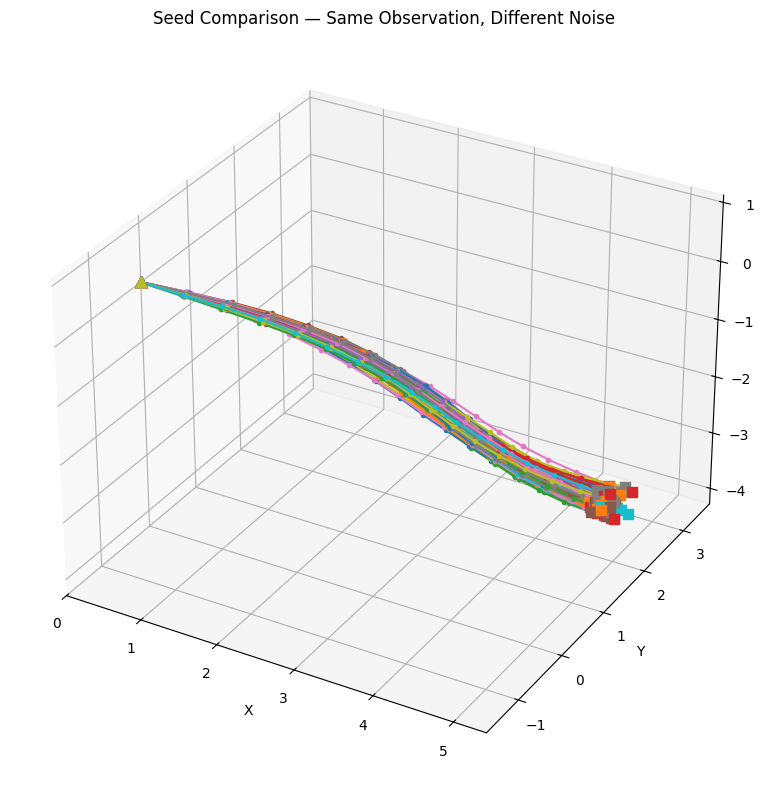

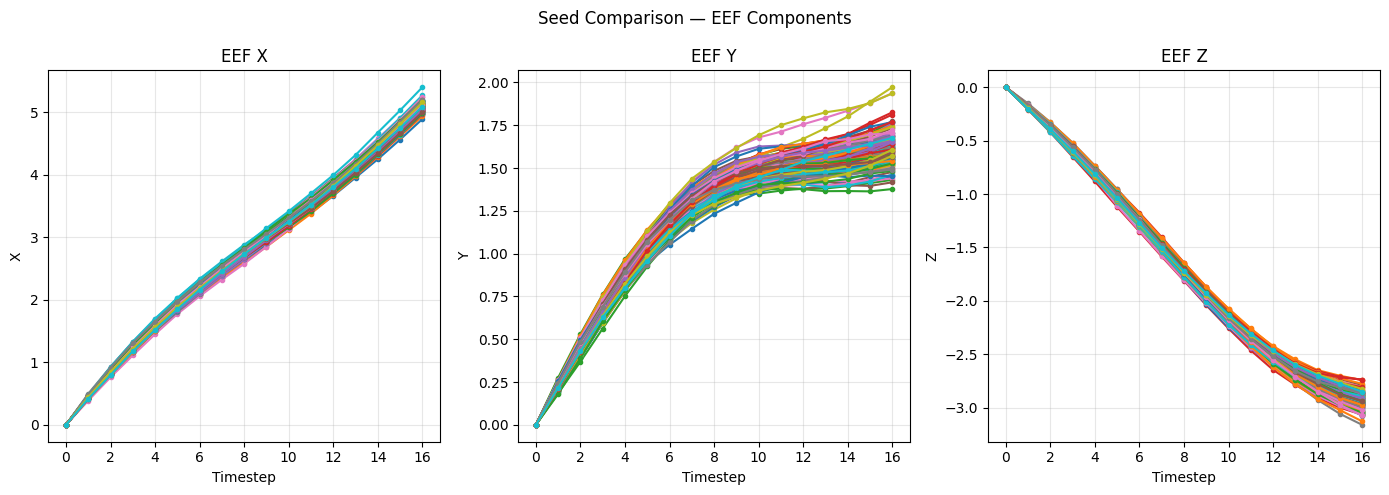

Across all timesteps:
  x: mean=2.6663, 	var=0.0030, 	std=0.0512, 	range=0.2880
  y: mean=1.1372, 	var=0.0043, 	std=0.0597, 	range=0.3084
  z: mean=-1.6336, 	var=0.0019, 	std=0.0386, 	range=0.1885
Across final timestep only:
  x: mean=5.0893, 	var=0.0057, 	std=0.0757, 	range=0.5098
  y: mean=1.6136, 	var=0.0117, 	std=0.1082, 	range=0.5947
  z: mean=-2.9391, 	var=0.0072, 	std=0.0851, 	range=0.4243


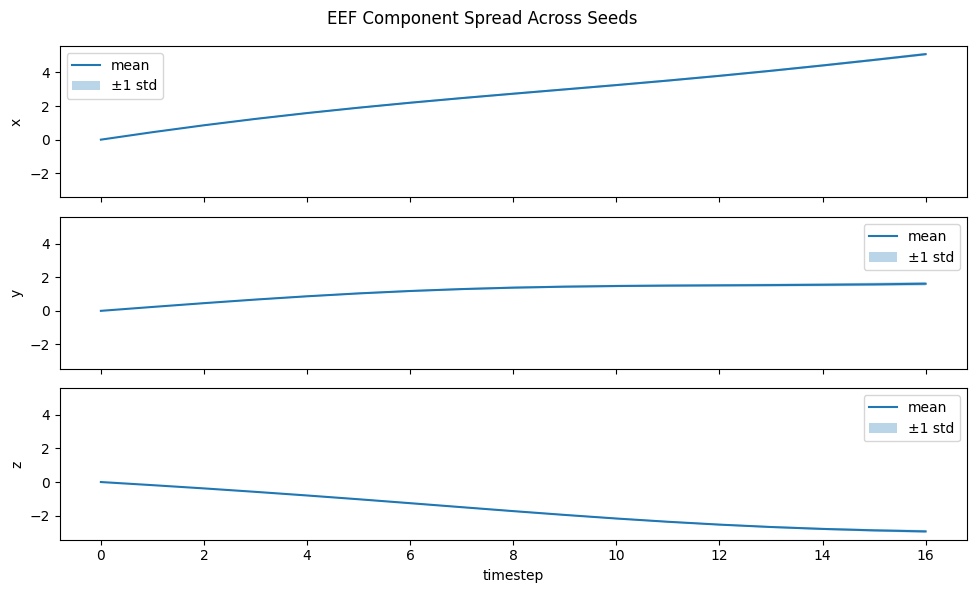

In [15]:
# Cell 11: Compare seeds --- different noise leads to very different action
viz_seeds = TrajectoryVisualizer()

for seed in range(100):
    r = lab.denoise(features, seed=seed)
    d = lab.decode_raw_actions(r.action_pred, features.states)
    viz_seeds.add_trajectory(d, f"seed={seed}", eef_key=EEF_KEY)

fig = viz_seeds.plot_eef_3d(title="Seed Comparison — Same Observation, Different Noise")
plt.show()

fig2 = viz_seeds.plot_eef_components(title="Seed Comparison — EEF Components")
plt.show()


# Plot Var for x/y/z EEF components
# Stack all trajectories: shape (n_seeds, T+1, 3)                                                                                                                                                                  
all_pos = np.stack([t["positions"] for t in viz_seeds.trajectories])                                                                                                                                               
                                                                                                                                                                                                            
# Per-component stats across seeds                                                                                                                                                                                 
mean = all_pos.mean(axis=0)  # (T+1, 3)                                                                                                                                                                            
var = all_pos.var(axis=0)    # (T+1, 3)                                                                                                                                                                            
rng = all_pos.max(axis=0) - all_pos.min(axis=0)  # (T+1, 3)                                                                                                                                                        
                                                                                                                                                                                                                    
# Per-component summary (stats across seeds at each timestep, then averaged)
labels = ["x", "y", "z"]
print("Across all timesteps:")
for i, l in enumerate(labels):
    print(f"  {l}: mean={mean[:, i].mean():.4f}, \tvar={var[:, i].mean():.4f}, \tstd={np.sqrt(var[:, i]).mean():.4f}, \trange={rng[:, i].mean():.4f}")

print("Across final timestep only:")
for i, l in enumerate(labels):
    print(f"  {l}: mean={mean[-1, i]:.4f}, \tvar={var[-1, i]:.4f}, \tstd={np.sqrt(var[-1, i]):.4f}, \trange={rng[-1, i]:.4f}")                                                                                                                 
                                                                                                                                                                                                                    
###                                                                                                
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True, sharey=True)                                                                                                                                                       
for i, l in enumerate(labels):                                                                                                                                                                                     
    axes[i].plot(mean[:, i], label="mean")                                                                                                                                                                         
    axes[i].fill_between(                                                                                                                                                                                          
        range(mean.shape[0]),                                                                                                                                                                                      
        mean[:, i] - np.sqrt(var[:, i]),                                                                                                                                                                           
        mean[:, i] + np.sqrt(var[:, i]),                                                                                                                                                                           
        alpha=0.3, label="±1 std",                                                                                                                                                                                 
    )                                                                                                                                                                                                              
    axes[i].set_ylabel(l)                                                                                                                                                                                          
    axes[i].legend()                                                                                                                                                                                               
axes[-1].set_xlabel("timestep")                                                                                                                                                                                    
plt.suptitle("EEF Component Spread Across Seeds")                                                                                                                                                                  
plt.tight_layout()                                                                                                                                                                                                 
plt.show()            

Let's try the next step, model is pretty decisive here...

Observation loaded from: /home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step012.npz
Keys: ['state.base_position', 'state.base_rotation', 'state.end_effector_position_absolute', 'state.end_effector_position_relative', 'state.end_effector_rotation_absolute', 'state.end_effector_rotation_relative', 'state.gripper_qpos', 'state.gripper_qvel', 'state.joint_position', 'state.joint_position_cos', 'state.joint_position_sin', 'state.joint_velocity', 'video.res256_image_side_0', 'video.res256_image_side_1', 'video.res256_image_wrist_0', 'video.res512_image_side_0', 'video.res512_image_side_1', 'video.res512_image_wrist_0', 'annotation.human.action.task_description']
  state.base_position: shape=(1, 1, 3), dtype=float32
  state.base_rotation: shape=(1, 1, 4), dtype=float32
  state.end_effector_position_absolute: shape=(1, 1, 3), dtype=float32
  state.end_effector_position_relative: shape=(1, 1, 3), dtype=float32
  state.end_effector_rotation_absolute: shape=(1, 1, 4), dtype=float32
  state

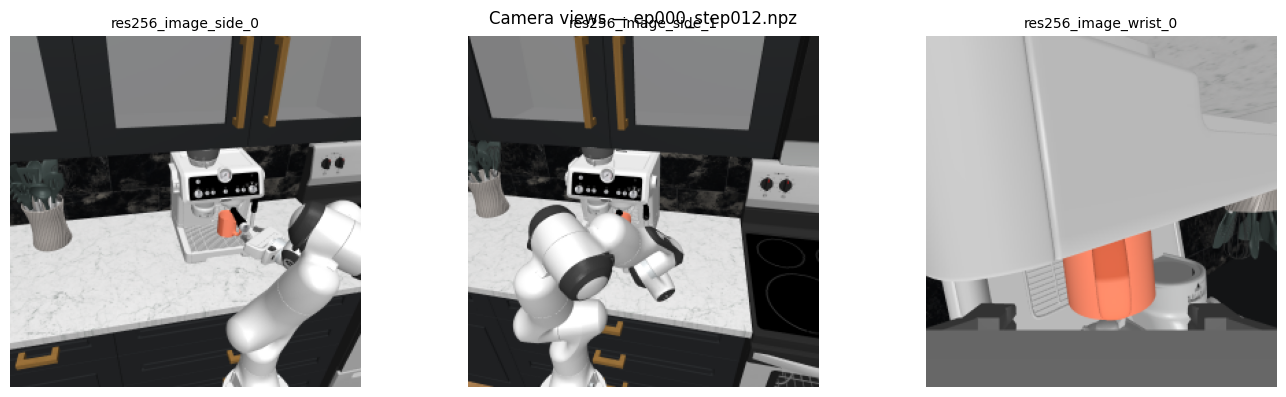

In [20]:
OBS_PATH = "/home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step012.npz"

obs = DenoisingLab.load_observation(OBS_PATH)
print("Observation loaded from:", OBS_PATH)
print("Keys:", list(obs.keys()))
for k, v in obs.items():
    if isinstance(v, np.ndarray):
        print(f"  {k}: shape={v.shape}, dtype={v.dtype}")
    else:
        print(f"  {k}: {v}")

# Shows what the robot sees — helps identify which .npz to experiment with
fig = DenoisingLab.plot_camera_views(obs, figsize=(14, 4))
plt.suptitle(f"Camera views — {OBS_PATH.split('/')[-1]}", fontsize=12)
plt.show()

features = lab.encode_features_from_sim_obs(obs)

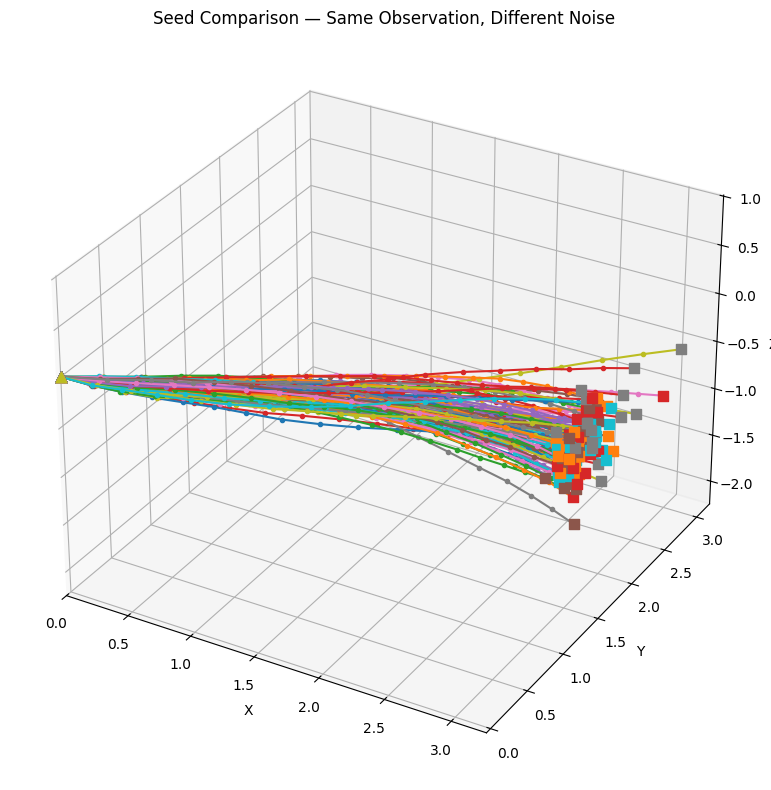

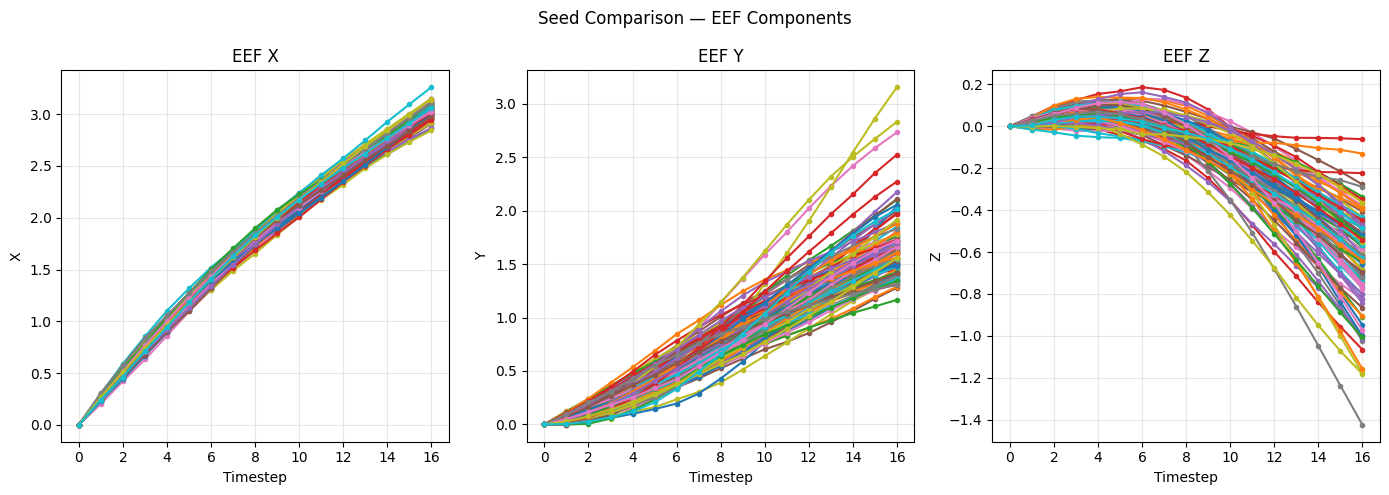

Across all timesteps:
  x: mean=1.6819, 	var=0.0022, 	std=0.0446, 	range=0.2335
  y: mean=0.7798, 	var=0.0321, 	std=0.1552, 	range=0.8569
  z: mean=-0.1474, 	var=0.0118, 	std=0.0860, 	range=0.4750
Across final timestep only:
  x: mean=3.0336, 	var=0.0046, 	std=0.0677, 	range=0.4170
  y: mean=1.6686, 	var=0.1052, 	std=0.3243, 	range=1.9906
  z: mean=-0.6254, 	var=0.0543, 	std=0.2330, 	range=1.3628


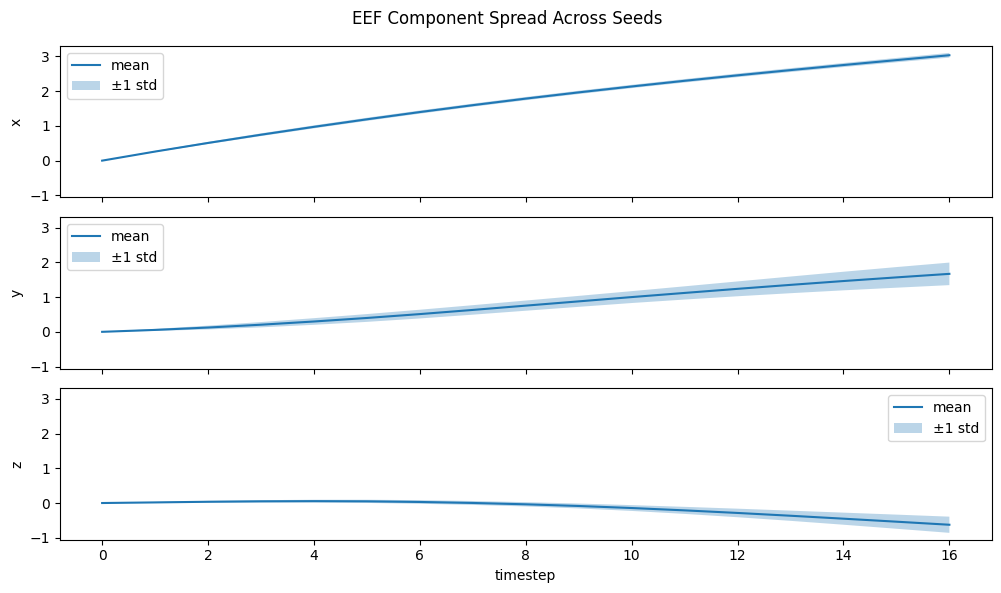

In [21]:
viz_seeds = TrajectoryVisualizer()

for seed in range(100):
    r = lab.denoise(features, seed=seed)
    d = lab.decode_raw_actions(r.action_pred, features.states)
    viz_seeds.add_trajectory(d, f"seed={seed}", eef_key=EEF_KEY)

fig = viz_seeds.plot_eef_3d(title="Seed Comparison — Same Observation, Different Noise")
plt.show()

fig2 = viz_seeds.plot_eef_components(title="Seed Comparison — EEF Components")
plt.show()


# Plot Var for x/y/z EEF components
# Stack all trajectories: shape (n_seeds, T+1, 3)                                                                                                                                                                  
all_pos = np.stack([t["positions"] for t in viz_seeds.trajectories])                                                                                                                                               
                                                                                                                                                                                                            
# Per-component stats across seeds                                                                                                                                                                                 
mean = all_pos.mean(axis=0)  # (T+1, 3)                                                                                                                                                                            
var = all_pos.var(axis=0)    # (T+1, 3)                                                                                                                                                                            
rng = all_pos.max(axis=0) - all_pos.min(axis=0)  # (T+1, 3)                                                                                                                                                        
                                                                                                                                                                                                                    
# Per-component summary (stats across seeds at each timestep, then averaged)
labels = ["x", "y", "z"]
print("Across all timesteps:")
for i, l in enumerate(labels):
    print(f"  {l}: mean={mean[:, i].mean():.4f}, \tvar={var[:, i].mean():.4f}, \tstd={np.sqrt(var[:, i]).mean():.4f}, \trange={rng[:, i].mean():.4f}")

print("Across final timestep only:")
for i, l in enumerate(labels):
    print(f"  {l}: mean={mean[-1, i]:.4f}, \tvar={var[-1, i]:.4f}, \tstd={np.sqrt(var[-1, i]):.4f}, \trange={rng[-1, i]:.4f}")                                                                                                                 
                                                                                                                                                                                                                    
###                                                                                                
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True, sharey=True)                                                                                                                                                       
for i, l in enumerate(labels):                                                                                                                                                                                     
    axes[i].plot(mean[:, i], label="mean")                                                                                                                                                                         
    axes[i].fill_between(                                                                                                                                                                                          
        range(mean.shape[0]),                                                                                                                                                                                      
        mean[:, i] - np.sqrt(var[:, i]),                                                                                                                                                                           
        mean[:, i] + np.sqrt(var[:, i]),                                                                                                                                                                           
        alpha=0.3, label="±1 std",                                                                                                                                                                                 
    )                                                                                                                                                                                                              
    axes[i].set_ylabel(l)                                                                                                                                                                                          
    axes[i].legend()                                                                                                                                                                                               
axes[-1].set_xlabel("timestep")                                                                                                                                                                                    
plt.suptitle("EEF Component Spread Across Seeds")                                                                                                                                                                  
plt.tight_layout()                                                                                                                                                                                                 
plt.show()            